Example 1: Simple 3x3 Symmetric Positive-Definite System

Matrix A:
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]

Right-hand side b:
[1. 2. 3.]

Cholesky factor L:
[[2.         0.         0.        ]
 [0.5        1.6583124  0.        ]
 [0.         0.60302269 1.2792043 ]]

Verification: L @ L^T (should equal A):
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]

Solution using Cholesky:
[0.22222222 0.11111111 1.44444444]

Solution using direct solver (for verification):
[0.22222222 0.11111111 1.44444444]

Error: 2.34e-16

Example 2: 2D Poisson Equation (50x50 grid)
This mimics the pressure equation in incompressible flow

Solving 2500x2500 system using Cholesky factorization...
Cholesky factorization completed in 0.248 seconds
Residual: 3.87e-13

Plot saved as 'cholesky_results.png'


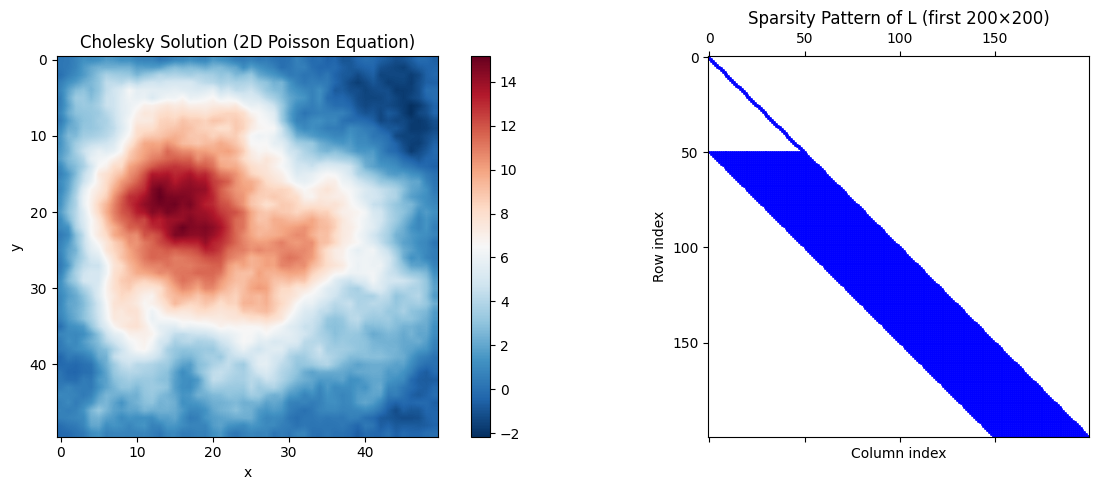


Method Comparison: Cholesky vs Conjugate Gradient

Cholesky Factorization:
  ✓ Direct method - gives exact solution (within machine precision)
  ✓ O(n³) time complexity, O(n²) space for dense matrices
  ✓ Best for: small to medium systems, multiple right-hand sides
  ✗ For sparse matrices, can have significant fill-in
  • Solution time: 0.248 seconds

Conjugate Gradient:
  ✓ Iterative method - approximate solution
  ✓ O(kn²) for sparse matrices (k << n iterations)
  ✓ O(n) space - only stores vectors, not matrices
  ✓ Best for: very large sparse systems
  ✗ Needs preconditioning for ill-conditioned systems

Key Observations:
• System size: 2500 unknowns
• Matrix is sparse (Poisson equation)
• Cholesky factor L has 125049 non-zeros
• Original matrix A has 12300 non-zeros
• Fill-in ratio: 10.17x

• For this sparse system, iterative methods (CG) are typically
  more efficient than direct methods (Cholesky)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

def cholesky_factorization(A):
    """
    Compute Cholesky factorization: A = L L^T
    where L is lower triangular
    
    Parameters:
    A: symmetric positive-definite matrix (n x n)
    
    Returns:
    L: lower triangular matrix
    """
    n = A.shape[0]
    L = np.zeros_like(A)
    
    for i in range(n):
        for j in range(i + 1):
            if i == j:
                # Diagonal elements
                sum_sq = sum(L[i, k]**2 for k in range(j))
                L[i, j] = np.sqrt(A[i, i] - sum_sq)
            else:
                # Off-diagonal elements
                sum_prod = sum(L[i, k] * L[j, k] for k in range(j))
                L[i, j] = (A[i, j] - sum_prod) / L[j, j]
    
    return L

def forward_substitution(L, b):
    """
    Solve L y = b for y (forward substitution)
    where L is lower triangular
    """
    n = len(b)
    y = np.zeros(n)
    
    for i in range(n):
        sum_val = sum(L[i, j] * y[j] for j in range(i))
        y[i] = (b[i] - sum_val) / L[i, i]
    
    return y

def backward_substitution(L, y):
    """
    Solve L^T x = y for x (backward substitution)
    where L^T is upper triangular
    """
    n = len(y)
    x = np.zeros(n)
    
    for i in range(n - 1, -1, -1):
        sum_val = sum(L[j, i] * x[j] for j in range(i + 1, n))
        x[i] = (y[i] - sum_val) / L[i, i]
    
    return x

def solve_cholesky(A, b):
    """
    Solve Ax = b using Cholesky factorization
    
    Steps:
    1. Factor: A = L L^T
    2. Solve: L y = b (forward substitution)
    3. Solve: L^T x = y (backward substitution)
    
    Parameters:
    A: symmetric positive-definite matrix (n x n)
    b: right-hand side vector (n,)
    
    Returns:
    x: solution vector
    L: Cholesky factor (for verification)
    """
    # Step 1: Cholesky factorization
    L = cholesky_factorization(A)
    
    # Step 2: Forward substitution (L y = b)
    y = forward_substitution(L, b)
    
    # Step 3: Backward substitution (L^T x = y)
    x = backward_substitution(L, y)
    
    return x, L

# Example 1: Simple 3x3 system
print("="*60)
print("Example 1: Simple 3x3 Symmetric Positive-Definite System")
print("="*60)

# Create a symmetric positive-definite matrix (same as CG example)
A1 = np.array([[4.0, 1.0, 0.0],
               [1.0, 3.0, 1.0],
               [0.0, 1.0, 2.0]])

b1 = np.array([1.0, 2.0, 3.0])

print("\nMatrix A:")
print(A1)
print("\nRight-hand side b:")
print(b1)

# Solve using Cholesky
x_chol, L1 = solve_cholesky(A1, b1)

print("\nCholesky factor L:")
print(L1)

print("\nVerification: L @ L^T (should equal A):")
print(L1 @ L1.T)

print("\nSolution using Cholesky:")
print(x_chol)

# Verify with direct solver
x_direct = np.linalg.solve(A1, b1)
print("\nSolution using direct solver (for verification):")
print(x_direct)

print(f"\nError: {np.linalg.norm(x_chol - x_direct):.2e}")

# Example 2: Larger system - 2D Poisson equation (same as CG example)
print("\n" + "="*60)
print("Example 2: 2D Poisson Equation (50x50 grid)")
print("="*60)
print("This mimics the pressure equation in incompressible flow")

def create_2d_poisson_matrix(n):
    """
    Create matrix for 2D Poisson equation using finite differences
    -∇²u = f on a square domain
    """
    N = n * n
    A = np.zeros((N, N))
    
    for i in range(n):
        for j in range(n):
            idx = i * n + j
            
            # Diagonal element
            A[idx, idx] = 4.0
            
            # Off-diagonal elements (neighbors)
            if i > 0:  # left neighbor
                A[idx, idx - n] = -1.0
            if i < n - 1:  # right neighbor
                A[idx, idx + n] = -1.0
            if j > 0:  # bottom neighbor
                A[idx, idx - 1] = -1.0
            if j < n - 1:  # top neighbor
                A[idx, idx + 1] = -1.0
    
    return A

# Grid size
n = 50
N = n * n

# Create Poisson matrix (same as CG example)
A2 = create_2d_poisson_matrix(n)

# Create right-hand side (using same random seed for fair comparison)
np.random.seed(42)
b2 = np.random.randn(N)

print(f"\nSolving {N}x{N} system using Cholesky factorization...")

# Solve using Cholesky (using NumPy's optimized version for large matrices)
start_time = time.time()
L2 = np.linalg.cholesky(A2)
y2 = np.linalg.solve(L2, b2)
x_chol2 = np.linalg.solve(L2.T, y2)
cholesky_time = time.time() - start_time

print(f"Cholesky factorization completed in {cholesky_time:.3f} seconds")

# Verify solution
residual = np.linalg.norm(A2 @ x_chol2 - b2)
print(f"Residual: {residual:.2e}")

# Reshape solution for visualization
x_grid = x_chol2.reshape(n, n)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Solution
im1 = axes[0].imshow(x_grid, cmap='RdBu_r', interpolation='bilinear')
axes[0].set_title('Cholesky Solution (2D Poisson Equation)', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

# Plot 2: Sparsity pattern of Cholesky factor
# For visualization, only show a corner of the matrix
corner_size = 200
L_corner = L2[:corner_size, :corner_size]
im2 = axes[1].spy(L_corner, markersize=1, color='blue')
axes[1].set_title(f'Sparsity Pattern of L (first {corner_size}×{corner_size})', fontsize=12)
axes[1].set_xlabel('Column index')
axes[1].set_ylabel('Row index')

plt.tight_layout()
plt.savefig('cholesky_results.png', dpi=150, bbox_inches='tight')
print("\nPlot saved as 'cholesky_results.png'")
plt.show()

print("\n" + "="*60)
print("Method Comparison: Cholesky vs Conjugate Gradient")
print("="*60)
print("\nCholesky Factorization:")
print("  ✓ Direct method - gives exact solution (within machine precision)")
print("  ✓ O(n³) time complexity, O(n²) space for dense matrices")
print("  ✓ Best for: small to medium systems, multiple right-hand sides")
print("  ✗ For sparse matrices, can have significant fill-in")
print(f"  • Solution time: {cholesky_time:.3f} seconds")

print("\nConjugate Gradient:")
print("  ✓ Iterative method - approximate solution")
print("  ✓ O(kn²) for sparse matrices (k << n iterations)")
print("  ✓ O(n) space - only stores vectors, not matrices")
print("  ✓ Best for: very large sparse systems")
print("  ✗ Needs preconditioning for ill-conditioned systems")

print("\n" + "="*60)
print("Key Observations:")
print("="*60)
print(f"• System size: {N} unknowns")
print(f"• Matrix is sparse (Poisson equation)")
print(f"• Cholesky factor L has {np.count_nonzero(L2)} non-zeros")
print(f"• Original matrix A has {np.count_nonzero(A2)} non-zeros")
print(f"• Fill-in ratio: {np.count_nonzero(L2) / np.count_nonzero(A2):.2f}x")
print("\n• For this sparse system, iterative methods (CG) are typically")
print("  more efficient than direct methods (Cholesky)")